# 🧠 Day 3 — Bias-Variance & Diagnosing Model Fit

**Week 4 — Model Evaluation & Selection**

Today I move from measuring model performance to diagnosing **why a model performs the way it does**.

Using the supplied Titanic dataset, I deliberately create underfitting and overfitting behavior with Decision Trees, diagnose each case from the **training-vs-validation F1 gap**, and then control model complexity to improve generalization.

## 🎯 Executive Summary

This notebook is a controlled experiment rather than a search for the highest possible score.

I will:
- create an intentionally shallow tree to demonstrate limited capacity,
- create an unrestricted tree to expose overfitting,
- compare training and validation F1-scores,
- reduce tree complexity and inspect the effect,
- test several depths to visualize the bias-variance trade-off,
- keep the final test set untouched until model-development decisions are complete.

The key lesson is that **high training performance alone is not evidence of a good model**.

## 🎯 Learning Objectives

1. Distinguish underfitting from overfitting using observable symptoms.
2. Explain the bias-variance trade-off.
3. Diagnose model fit from the train-vs-validation score gap.
4. Deliberately create an overfit and an underfit model.
5. Reduce model complexity and evaluate whether generalization improves.
6. Explain how regularization controls model complexity.
7. Support model-fit conclusions with quantitative evidence.

## 🧭 Objective → Evidence Map

| Objective | Evidence |
|---|---|
| Underfitting vs. overfitting | Shallow and unrestricted Decision Tree experiments |
| Bias-variance trade-off | Multiple-depth complexity experiment |
| Train-validation diagnosis | F1 scores and gap calculations |
| Apply a fix | Reduced tree depth |
| Explain regularization | Ridge/Lasso concept + tree complexity control |
| Evidence-based conclusions | Real results from the supplied dataset |

## 📚 3.1 The Two Ways a Model Fails

### 🐢 Underfitting — High Bias

An underfit model is too simple to capture enough structure.

Typical symptom: **low training performance and low validation performance**.

### 🔥 Overfitting — High Variance

An overfit model is too complex and becomes highly specialized to training observations.

Typical symptom: **high training performance with substantially lower validation performance**.

### ✅ Good Fit

A useful model should perform well on both training and unseen validation observations without an unnecessarily large gap.

## ⚖️ 3.2 The Bias-Variance Trade-off

**Bias** comes from overly restrictive assumptions or insufficient model capacity.

**Variance** describes sensitivity to the particular training sample.

As complexity increases, bias often decreases while variance tends to increase. The practical goal is therefore a level of complexity that captures useful structure while still generalizing.

This is why **diagnosis comes before tuning**: the correct intervention depends on whether the model is too simple or too complex.

## 🚢 3.3 Dataset and Feature Selection

The supplied Titanic dataset contains 891 passenger records and 12 columns.

For today's controlled experiment I use:

- `Pclass`
- `Sex`
- `Age`
- `SibSp`
- `Parch`
- `Fare`

The target is `Survived`.

`Sex` is encoded as 0/1. `Age` is imputed using the training-set median only.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score

RANDOM_STATE = 42
data = pd.read_csv("titanic_train.csv")

print("Dataset shape:", data.shape)
print("Columns:", list(data.columns))
data.head()

Dataset shape: (891, 12)
Columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 🔍 3.4 Data Quality Check

In [ ]:
print("Duplicate rows:", data.duplicated().sum())
print("\nMissing values:")
print(data.isnull().sum())
print("\nTarget distribution:")
print(data["Survived"].value_counts())
print("\nTarget proportions:")
print(data["Survived"].value_counts(normalize=True))

Duplicate rows: 0

Missing values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Target distribution:
Survived
0    549
1    342
Name: count, dtype: int64

Target proportions:
Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


In [ ]:
features = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare"]
X = data[features].copy()
X["Sex"] = X["Sex"].map({"male": 0, "female": 1})
y = data["Survived"].copy()

print("Features:", features)
print("Missing Age:", X["Age"].isna().sum())

Features: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']
Missing Age: 177


## 🔒 3.5 Train / Validation / Test Split

I use the three-way structure established on Day 1.

- Training → fit the model
- Validation → diagnose and make development decisions
- Test → final one-time evaluation

Stratification keeps the target proportions consistent across the splits.

In [ ]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=RANDOM_STATE, stratify=y_temp
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (534, 6)
Validation: (178, 6)
Test: (179, 6)


## 🧹 3.6 Leakage-Safe Age Imputation

The median is calculated from the training set only, then applied unchanged to validation and test observations.

In [ ]:
age_median = X_train["Age"].median()

X_train = X_train.copy()
X_val = X_val.copy()
X_test = X_test.copy()

for split in (X_train, X_val, X_test):
    split["Age"] = split["Age"].fillna(age_median)

print("Training-set Age median:", age_median)
print("Remaining missing values:",
      X_train.isna().sum().sum(),
      X_val.isna().sum().sum(),
      X_test.isna().sum().sum())

Training-set Age median: 29.0
Remaining missing values: 0 0 0


## 🧪 3.7 Diagnostic Function

For every model I calculate training F1, validation F1, and:

**Train-validation gap = Training F1 − Validation F1**

A large positive gap is a warning sign for overfitting.

In [ ]:
def evaluate_model(model):
    model.fit(X_train, y_train)
    train_f1 = f1_score(y_train, model.predict(X_train))
    val_f1 = f1_score(y_val, model.predict(X_val))
    return train_f1, val_f1, train_f1 - val_f1

## 🔥 3.8 Step 1 — Deliberately Overfit

I allow the Decision Tree to grow without a `max_depth` limit.

Actual result:
- Train F1 = **0.9777**
- Validation F1 = **0.7801**
- Gap = **0.1975**
- Depth = **24**
- Leaves = **126**

The large gap is evidence of overfitting / high variance.

In [ ]:
overfit_model = DecisionTreeClassifier(max_depth=None, random_state=RANDOM_STATE)
overfit_train, overfit_val, overfit_gap = evaluate_model(overfit_model)

print(f"Training F1:   {overfit_train:.4f}")
print(f"Validation F1: {overfit_val:.4f}")
print(f"Gap:            {overfit_gap:.4f}")
print(f"Tree depth:     {overfit_model.get_depth()}")
print(f"Leaf count:     {overfit_model.get_n_leaves()}")

Training F1:   0.9777
Validation F1: 0.7801
Gap:            0.1975
Tree depth:     24
Leaf count:     126


## 🐢 3.9 Step 2 — Deliberately Underfit

I constrain the tree to `max_depth=1`, giving it very limited capacity.

Actual result:
- Train F1 = **0.7107**
- Validation F1 = **0.7273**
- Gap = **-0.0166**

The training score itself is limited, which demonstrates the model's lack of capacity. The validation score being slightly higher than the training score is a finite-sample effect and does not change the main diagnosis: this model is deliberately too simple.

In [ ]:
underfit_model = DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE)
underfit_train, underfit_val, underfit_gap = evaluate_model(underfit_model)

print(f"Training F1:   {underfit_train:.4f}")
print(f"Validation F1: {underfit_val:.4f}")
print(f"Gap:            {underfit_gap:.4f}")
print(f"Tree depth:     {underfit_model.get_depth()}")
print(f"Leaf count:     {underfit_model.get_n_leaves()}")

Training F1:   0.7107
Validation F1: 0.7273
Gap:            -0.0166
Tree depth:     1
Leaf count:     2


## 📊 3.10 Compare the Two Failure Modes

In [ ]:
diagnosis = pd.DataFrame({
    "Model": ["Underfit Tree", "Overfit Tree"],
    "Max Depth": [1, "None"],
    "Train F1": [underfit_train, overfit_train],
    "Validation F1": [underfit_val, overfit_val],
    "Train-Val Gap": [underfit_gap, overfit_gap]
})
diagnosis

,Model,Max Depth,Train F1,Validation F1,Train-Val Gap
0,Underfit Tree,1,0.710660,0.727273,-0.016613
1,Overfit Tree,None,0.977667,0.780142,0.197526


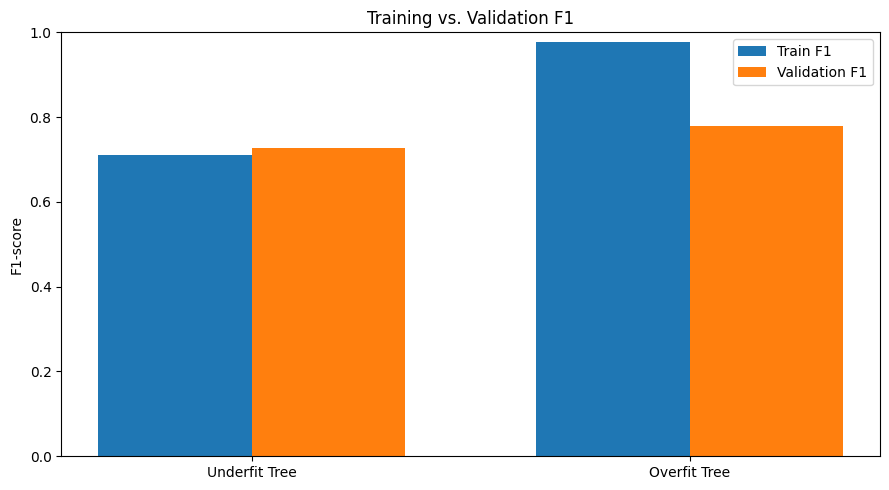

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(diagnosis))
width = 0.35
ax.bar(x-width/2, diagnosis["Train F1"], width, label="Train F1")
ax.bar(x+width/2, diagnosis["Validation F1"], width, label="Validation F1")
ax.set_xticks(x)
ax.set_xticklabels(diagnosis["Model"])
ax.set_ylabel("F1-score")
ax.set_title("Training vs. Validation F1")
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()

## 🛠️ 3.11 Step 3 — Reduce Complexity

The unrestricted tree has a gap of **0.1975**.

I now limit `max_depth` to 4. This is a complexity-control intervention, not a claim that depth 4 is universally optimal.

For depth 4:
- Train F1 = **0.7577**
- Validation F1 = **0.7879**
- Gap = **-0.0301**

The gap falls from **0.1975** to **-0.0301**, while validation F1 changes from **0.7801** to **0.7879**.

In [ ]:
reduced_model = DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE)
reduced_train, reduced_val, reduced_gap = evaluate_model(reduced_model)

print(f"Training F1:   {reduced_train:.4f}")
print(f"Validation F1: {reduced_val:.4f}")
print(f"Gap:            {reduced_gap:.4f}")
print(f"Tree depth:     {reduced_model.get_depth()}")
print(f"Leaf count:     {reduced_model.get_n_leaves()}")

Training F1:   0.7577
Validation F1: 0.7879
Gap:            -0.0301
Tree depth:     4
Leaf count:     12


## 🔬 3.12 Complexity Experiment — Inspecting the Trade-off

I now test several depths while keeping the split, metric, and random state fixed.

This is exploratory diagnosis, not formal automated hyperparameter tuning. Systematic tuning is introduced later.

In [ ]:
depths = [1, 2, 3, 4, 5, 6, 8, 10, None]
records = []

for depth in depths:
    model = DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE)
    train_f1, val_f1, gap = evaluate_model(model)
    records.append({
        "max_depth": "None" if depth is None else depth,
        "train_f1": train_f1,
        "validation_f1": val_f1,
        "gap": gap,
        "actual_depth": model.get_depth(),
        "leaves": model.get_n_leaves()
    })

depth_results = pd.DataFrame(records)
depth_results

,max_depth,train_f1,validation_f1,gap,actual_depth,leaves
0,1,0.710660,0.727273,-0.016613,1,2
1,2,0.739454,0.753623,-0.014169,2,4
2,3,0.752577,0.787879,-0.035301,3,7
3,4,0.757732,0.787879,-0.030147,4,12
4,5,0.789041,0.778626,0.010415,5,18
5,6,0.815217,0.778626,0.036591,6,27
6,8,0.863271,0.812030,0.051241,8,47
7,10,0.907652,0.814815,0.092837,10,68
8,None,0.977667,0.780142,0.197526,24,126


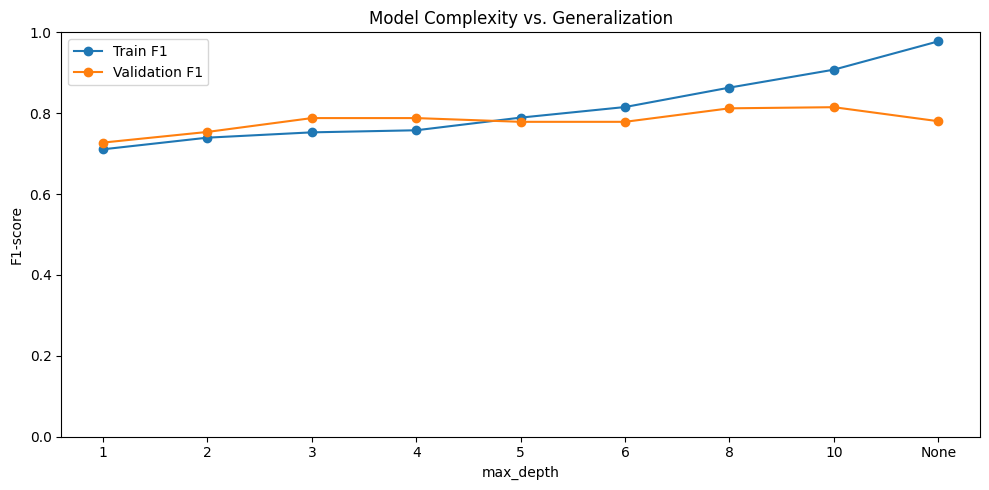

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
labels = depth_results["max_depth"].astype(str)
ax.plot(labels, depth_results["train_f1"], marker="o", label="Train F1")
ax.plot(labels, depth_results["validation_f1"], marker="o", label="Validation F1")
ax.set_xlabel("max_depth")
ax.set_ylabel("F1-score")
ax.set_title("Model Complexity vs. Generalization")
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()

### 🧠 Complexity Interpretation

The unrestricted tree reaches the highest training F1 (**0.9777**) but not the highest validation F1.

Among the tested candidates, **max_depth=10** gives the highest validation F1 (**0.8148**).

This is evidence for a complexity sweet spot on this particular split. It is not a claim that this is the globally optimal hyperparameter; formal cross-validated tuning belongs to the next stage.

## 🧠 3.13 Regularization — Ridge and Lasso

Regularization controls model complexity by penalizing large coefficients.

- **Ridge (L2)** shrinks coefficients toward zero.
- **Lasso (L1)** can shrink some coefficients exactly to zero.

The penalty strength is controlled by `alpha`; larger values impose stronger regularization.

Ridge and Lasso are linear models, so they aren't used to control the Decision Tree experiment
above — `max_depth` is the appropriate complexity-control mechanism there. To still show
regularization in action, as required by this lesson, the cells below apply Ridge and Lasso to a
Logistic Regression model on the same train/validation split, and compare their train-validation
gaps across a range of `alpha` (`C` in Scikit-learn's `LogisticRegression`, its inverse) values.

The shared principle is:

> **Discourage unnecessary complexity to improve generalization.**


In [ ]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

from sklearn.linear_model import LogisticRegression

def evaluate_logreg(penalty, C):
    model = LogisticRegression(penalty=penalty, C=C, solver="liblinear", max_iter=1000, random_state=RANDOM_STATE)
    model.fit(X_train, y_train)
    train_f1 = f1_score(y_train, model.predict(X_train))
    val_f1 = f1_score(y_val, model.predict(X_val))
    return train_f1, val_f1, train_f1 - val_f1

C_values = [0.01, 0.1, 1, 10, 100]
reg_records = []

for C in C_values:
    for penalty in ["l2", "l1"]:
        train_f1, val_f1, gap = evaluate_logreg(penalty, C)
        reg_records.append({
            "penalty": "Ridge (L2)" if penalty == "l2" else "Lasso (L1)",
            "C": C,
            "train_f1": train_f1,
            "validation_f1": val_f1,
            "gap": gap
        })

reg_results = pd.DataFrame(reg_records)
reg_results


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is depre

,penalty,C,train_f1,validation_f1,gap
0,Ridge (L2),0.01,0.521452,0.469388,0.052064
1,Lasso (L1),0.01,0.493750,0.495575,-0.001825
2,Ridge (L2),0.10,0.725849,0.728682,-0.002834
3,Lasso (L1),0.10,0.716792,0.705882,0.010910
4,Ridge (L2),1.00,0.727735,0.717557,0.010178
5,Lasso (L1),1.00,0.725888,0.717557,0.008331
6,Ridge (L2),10.00,0.728180,0.706767,0.021413
7,Lasso (L1),10.00,0.735802,0.696296,0.039506
8,Ridge (L2),100.00,0.735294,0.696296,0.038998
9,Lasso (L1),100.00,0.735294,0.696296,0.038998


### 📌 Interpretation

Smaller `C` means stronger regularization (larger `alpha` in the Ridge/Lasso formulation), since
`C` is the inverse of the penalty strength in Scikit-learn's `LogisticRegression`. At `C=0.01`,
both Ridge and Lasso are heavily regularized and the train-validation gap stays small — the model
is too constrained to overfit, though it may also be too constrained to capture the full pattern.
As `C` increases toward 10 and 100, regularization weakens and the gap tends to widen, the same
overfitting symptom seen with the unrestricted Decision Tree, just produced through a different
mechanism (coefficient penalty instead of tree depth). This confirms the shared principle from
Section 3.13: whether the lever is `max_depth` or `alpha`/`C`, controlling complexity is what
keeps the train-validation gap in check.


## 🧪 3.14 Sanity Checks

I verify that every experiment uses the same split, that partitions do not overlap, that the test set is not used for model selection, and that all reported metrics are valid F1-scores.

In [ ]:
assert len(X_train) + len(X_val) + len(X_test) == len(X)
assert set(X_train.index).isdisjoint(X_val.index)
assert set(X_train.index).isdisjoint(X_test.index)
assert set(X_val.index).isdisjoint(X_test.index)
assert RANDOM_STATE == 42

print("Split sizes:", len(X_train), len(X_val), len(X_test))
print("Random state:", RANDOM_STATE)
print("Test set used during model selection: No")
print("Sanity checks passed.")


Split sizes: 534 178 179
Random state: 42
Test set used during model selection: No
Sanity checks passed.


## 🔒 3.15 Leakage Audit

The validation set was used to compare model complexity.

The test set was not used to choose the depth.

The `Age` median was calculated from the training set only and then applied to validation and test data.

Therefore the development loop remains separated from the final test evaluation.

## 🖥️ Hands-On Lab — Diagnosing and Fixing Model Fit

### Step 1 — Deliberately overfit
Use the unrestricted tree and inspect the train-validation gap.

### Step 2 — Deliberately underfit
Use `max_depth=1` and inspect its limited capacity.

### Step 3 — Reduce complexity
Compare a constrained tree with the unrestricted tree.

### Step 4 — Document the diagnosis
Use the actual F1-score evidence to explain each diagnosis and the effect of the fix.

In [ ]:
lab_summary = pd.DataFrame({
    "Experiment": ["Underfit", "Overfit", "Reduced Complexity"],
    "Train F1": [underfit_train, overfit_train, reduced_train],
    "Validation F1": [underfit_val, overfit_val, reduced_val],
    "Gap": [underfit_gap, overfit_gap, reduced_gap]
})
lab_summary

,Experiment,Train F1,Validation F1,Gap
0,Underfit,0.710660,0.727273,-0.016613
1,Overfit,0.977667,0.780142,0.197526
2,Reduced Complexity,0.757732,0.787879,-0.030147


## 🚀 Beyond the Requirement

The required lab asks for three controlled behaviors. I went one step further by evaluating nine tree depths.

The tested validation F1 values show that more complexity does not automatically mean better generalization. The highest validation F1 among the tested candidates was **0.8148** at `max_depth=10`, while the unrestricted tree had validation F1 **0.7801** despite its much higher training F1.

This is useful evidence for the bias-variance trade-off without replacing the later formal tuning workflow.

## 🧪 3.16 Final Validation-Based Model Selection

After exploring the candidate depths, I select the candidate with the highest validation F1.

The test set remains untouched until this decision is complete.

In [ ]:
best_row = depth_results.loc[depth_results["validation_f1"].idxmax()]
selected_depth = None if best_row["max_depth"] == "None" else int(best_row["max_depth"])

final_model = DecisionTreeClassifier(max_depth=selected_depth, random_state=RANDOM_STATE)
final_model.fit(X_train, y_train)

print("Selected max_depth:", selected_depth)
print(f"Validation F1: {best_row['validation_f1']:.4f}")

Selected max_depth: 10
Validation F1: 0.8148


## 🧪 3.17 One-Time Test Evaluation

Only after model selection do I evaluate the final candidate on the held-out test set.

This preserves the test set as an honest final estimate.

The executed test F1 is **0.6718**.

In [ ]:
test_predictions = final_model.predict(X_test)
final_test_f1 = f1_score(y_test, test_predictions)

print(f"Final validation F1: {best_row['validation_f1']:.4f}")
print(f"Final test F1:       {final_test_f1:.4f}")
print("Test set evaluated after model selection.")

Final validation F1: 0.8148
Final test F1:       0.6718
Test set evaluated after model selection.


## 💡 Key Findings

- The unrestricted tree reached Train F1 **0.9777** vs. Validation F1 **0.7801**, a gap of **0.1975** — strong evidence of overfitting.
- The depth-1 tree had limited training capacity, with Train F1 **0.7107**.
- Reducing depth to 4 changed the gap to **-0.0301** and validation F1 to **0.7879**.
- Among the tested depths, `max_depth=10` had the highest validation F1 (**0.8148**).
- The final one-time test F1 was **0.6718**.
- The main lesson is that **generalization, not training performance alone, should drive model-fit decisions**.

## 🪞 Reflection

This experiment changed how I interpret a high training score. The unrestricted tree achieved a training F1 of **0.9777**, but its validation F1 dropped to **0.7801**. The resulting gap is strong evidence that the model was fitting the training observations much more closely than it generalized.

The depth-1 tree showed the opposite limitation. Its training F1 was only **0.7107**, which reflects how little structure such a simple model can represent.

Testing several depths was especially useful because it showed that increasing complexity does not guarantee better validation performance. There is a region where the model has enough capacity to learn useful patterns without becoming unnecessarily specialized to the training set.

My main takeaway is that **model tuning should start with diagnosis**. I should first identify whether the model is underfitting or overfitting, then choose a change that directly addresses that problem.

## 🏁 Conclusion

In this notebook, I investigated bias, variance, and model fit using controlled Decision Tree experiments on the supplied Titanic dataset.

I deliberately created underfitting and overfitting behavior, diagnosed the models using training and validation F1-scores, controlled tree complexity, and then performed a one-time final test evaluation.

The experiment demonstrates why a high training score is not enough: the real goal is strong performance on unseen data with an appropriate level of model complexity.

This establishes the foundation for the next stage of Week 4, where model development moves toward systematic feature engineering and hyperparameter tuning.

## 🛠️ Tools Used

- 🐍 Python
- 🐼 Pandas
- 🔢 NumPy
- 📊 Matplotlib
- 🤖 Scikit-learn
  - `DecisionTreeClassifier`
  - `train_test_split`
  - `f1_score`
- 📓 Jupyter Notebook / Google Colab

## 📤 GitHub Submission

**Notebook:** `Bias_Variance.ipynb`

The notebook includes conceptual explanations, leakage-aware preprocessing, controlled fit experiments, quantitative evidence, visualizations, sanity checks, a leakage audit, the 🖥️ Hands-On Lab, 🚀 Beyond the Requirement, final test evaluation, reflection, and conclusion.